In [41]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from Bootstraping import *



In [23]:
class ReadoutNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(4*300, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        # x: (batch, 4, 300)
        x = x.view(x.shape[0], -1)  # flatten → (batch, 1200)
        return self.net(x)

In [ ]:
x = torch.randn(32, 4, 300)
model = ReadoutNet()
out = model(x)

print(out.shape)  # (32, 4)

In [ ]:
pred = torch.argmax(model(x), dim=1)

In [20]:

class ReadoutDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [ ]:
dark_click_rate = 0.01
signal_click_rate = 0.01
nro = 300
samples = np.random.poisson(dark_click_rate, size=nro)
data_points = 10

values = [0, 1, 2]
fast_cross_relax = 300
slow_cross_relax = 3000
probs = [1-1/300, 1/300, 1/3000]   # must sum to 1

x = np.random.choice(values, p=probs, size=nro)

X = np.zeros(data_points,4,300)


In [87]:

values = [0, 1, 2]
probs = np.array([1 - 1/300 - 1/3000, 1/300, 1/3000])


def get_trace(nro, init_state=0,
              dark_rate=0.07,
              signal_rate=0.07):

    # --- sample randomness upfront ---
    flips = np.random.choice(values, size=nro, p=probs)

    dark = np.random.poisson(dark_rate, size=(4, nro))
    signal = np.random.poisson(signal_rate, size=nro)

    # --- output ---
    counts = dark.copy()

    s = init_state

    for t in range(nro):

        # add signal to current state
        counts[s, t] += signal[t]

        # evolve state
        f = flips[t]

        if f == 1:
            # fast channel: (0<->1), (2<->3)
            if s == 0:
                s = 1
            elif s == 1:
                s = 0
            elif s == 2:
                s = 3
            elif s == 3:
                s = 2

        elif f == 2:
            # slow channel: (0<->2), (1<->3)
            if s == 0:
                s = 2
            elif s == 2:
                s = 0
            elif s == 1:
                s = 3
            elif s == 3:
                s = 1

    return np.cumsum(counts, axis=1)

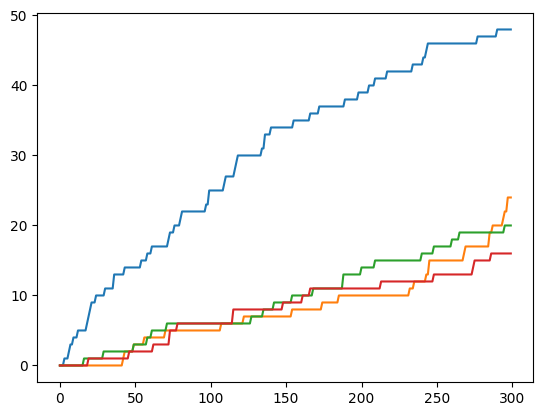

In [88]:
x = get_trace(300)

plt.plot(x[0])
plt.plot(x[1])
plt.plot(x[2])
plt.plot(x[3])
X_data = np.array([get_trace(300,init_state = k%4) for k in range(10000)])
Y_data = np.array([k%4 for k in range(10000)])


    

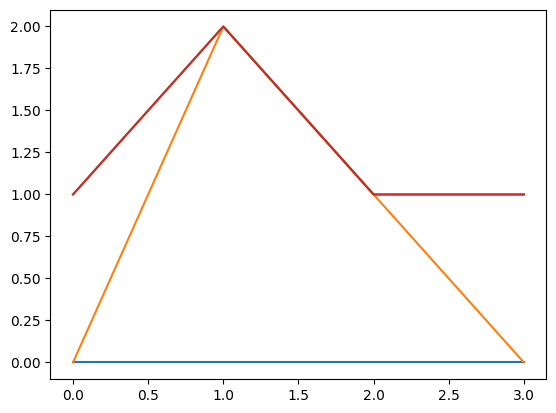

In [110]:
plt.plot(meas_counts[0,0,0])
plt.plot(meas_counts[0,0,1])
plt.plot(meas_counts[0,0,2])
plt.plot(meas_counts[0,0,3])



In [43]:
dataset = ReadoutDataset(X_data, Y_data)
loader = DataLoader(dataset, batch_size=400, shuffle=True)

In [44]:
# model = ReadoutNet()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
losses = []
for epoch in range(1000):
    for x_batch, y_batch in loader:

        logits = model(x_batch)

        loss = criterion(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    print(f"epoch {epoch}, loss {loss.item():.4f}")

epoch 0, loss 0.2555
epoch 1, loss 0.2935
epoch 2, loss 0.2690
epoch 3, loss 0.1974
epoch 4, loss 0.2344
epoch 5, loss 0.2971
epoch 6, loss 0.2365
epoch 7, loss 0.2599
epoch 8, loss 0.2506
epoch 9, loss 0.2874
epoch 10, loss 0.2381
epoch 11, loss 0.2437
epoch 12, loss 0.2769
epoch 13, loss 0.2694
epoch 14, loss 0.2522
epoch 15, loss 0.2714
epoch 16, loss 0.2559
epoch 17, loss 0.2419
epoch 18, loss 0.2576
epoch 19, loss 0.2181
epoch 20, loss 0.2096
epoch 21, loss 0.2386
epoch 22, loss 0.2456
epoch 23, loss 0.2650
epoch 24, loss 0.2612
epoch 25, loss 0.2727
epoch 26, loss 0.2889
epoch 27, loss 0.2916
epoch 28, loss 0.2738
epoch 29, loss 0.2354
epoch 30, loss 0.2993
epoch 31, loss 0.2751
epoch 32, loss 0.2514
epoch 33, loss 0.2739
epoch 34, loss 0.2185
epoch 35, loss 0.2581
epoch 36, loss 0.2032
epoch 37, loss 0.2318
epoch 38, loss 0.2034
epoch 39, loss 0.2401
epoch 40, loss 0.2592
epoch 41, loss 0.2636
epoch 42, loss 0.3132
epoch 43, loss 0.2199
epoch 44, loss 0.2509
epoch 45, loss 0.240

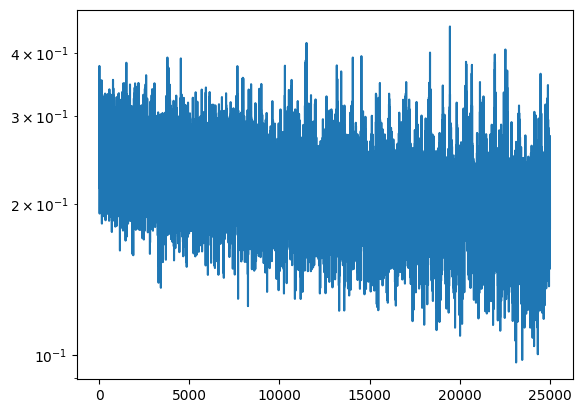

In [63]:
plt.plot(losses)
plt.yscale('log')

In [62]:
counts = 0
print(X_data.shape)

model.eval()

with torch.no_grad():
    
    for i,x in enumerate(X_data):
        x = torch.tensor(x, dtype=torch.float32)
        x = x.unsqueeze(0)

        ps =  model(x)
        s = np.argmax(ps)
    
        if s == Y_data[i]:
            counts+=1
    print(counts/len(X_data))
       
   

(10000, 4, 300)
0.9342


In [42]:
dirpath = 'Z:/SPIN-001/Run2 [BFp4]/NuclearReadout_With_tracking_XY_read_out/'
filename = '20260316000131__NuclearReadout_With_tracking_XY_read_out.hdf5' 
signal = load_h5_to_dic(dirpath + filename)[0]

In [108]:


clicksX = signal['clicksX']
clicks = clicksX[:,:,:,:]
r = 400


meas_counts = np.array([np.array([clicks[:,:,:nro,i].sum(-1) for nro in range(r)]) for i in range(4)])
meas_counts = meas_counts.transpose(2,0, 1, 3)

meas_counts.shape

(433, 4, 400, 4)

In [77]:
counts = 0
print(X_data.shape)

model.eval()

with torch.no_grad():
    
    for i,x in enumerate(meas_counts):
        x = torch.tensor(x, dtype=torch.float32)
        x = x.unsqueeze(0)

        ps =  model(x)
        s = np.argmax(ps)
    
        if s == 0:
            counts+=1
    print(counts/len(X_data))
       
   

(10000, 4, 300)
0.0348
